# Resonance Gain Surface for LKIPA

In [20]:
import os
import sys

import matplotlib.pyplot as plt
%matplotlib widget
from matplotlib import cm
from matplotlib.colors import Normalize
import numpy as np
from tqdm import tqdm

Step 1: Extract data from ```.csv``` file

In [21]:
RG_dataset = np.genfromtxt(
    fname='pump_settings_dc04-06_rf015-03.csv',
    delimiter=',',
    dtype=None,
    names=True
)
print(np.shape(RG_dataset))

(1694,)


In [22]:
dc_bias_list = np.array(RG_dataset['dc_bias'])
RF_list = np.array(RG_dataset['rf_pump'])
fp2_list = np.array(RG_dataset['fp2'])
idl_gain_list = np.array(RG_dataset['idl_gain'])
stable_list = np.array(RG_dataset['stable'])
print(dc_bias_list)

[0.   0.4  0.41 ... 0.58 0.59 0.6 ]


Step 2: Assemble 2-D grid of dc bias and rf pump values, and assign fp and gain values for grid

In [23]:
dc_unique = np.unique(dc_bias_list)
rf_unique = np.unique(RF_list)


fp2_grid = np.full((len(dc_unique), len(rf_unique)), np.nan)
gain_grid = np.full((len(dc_unique), len(rf_unique)), np.nan)
stable_grid = np.full((len(dc_unique), len(rf_unique)), False, dtype=bool)

dc_index = {val: i for i, val in enumerate(dc_unique)}
rf_index = {val: j for j, val in enumerate(rf_unique)}

fp2_grid = np.full((len(dc_unique), len(rf_unique)), np.nan)
gain_grid = np.full((len(dc_unique), len(rf_unique)), np.nan)
stable_grid = np.full((len(dc_unique), len(rf_unique)), False, dtype=bool)

for dc, rf, fp2, gain, stable in zip(dc_bias_list, RF_list, fp2_list, idl_gain_list, stable_list):
    i = dc_index[dc]
    j = rf_index[rf]

    fp2_grid[i, j] = fp2
    stable_grid[i, j] = stable

    if stable == False:     
        gain_grid[i, j] = 0
    else:     
        gain_grid[i, j] = gain
RF_grid, DC_grid = np.meshgrid(rf_unique[1:], dc_unique[1:])


In [24]:
  
fp2_grid  =  fp2_grid[1:, 1:]
gain_grid = gain_grid[1:, 1:]


# RF_grid = RF_grid[:, ::-1]
# fp2_grid = fp2_grid[:, ::-1]
# gain_grid = gain_grid[:, ::-1]
# stable_grid = stable_grid[:, ::-1]
#print(np.shapeRF_grid) 

# Plot 3-d Resonance Gain Surface

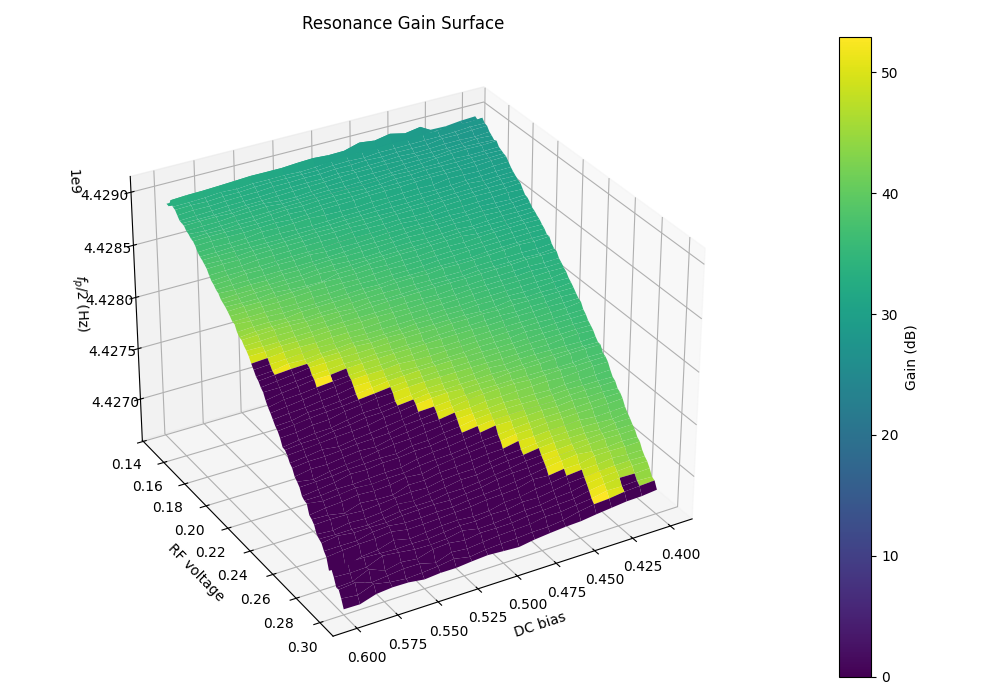

In [31]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Normalize gain values for the colormap
norm = Normalize(vmin=np.nanmin(gain_grid), vmax=np.nanmax(gain_grid))
facecolors = cm.viridis(norm(gain_grid))

# Surface plot: z = fp2, color = gain
surf = ax.plot_surface(
    DC_grid,
    RF_grid,
    fp2_grid,
    facecolors=facecolors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=True,
    shade=False
)
ax.view_init(elev=30, azim=60)

# Add a colorbar for gain
mappable = cm.ScalarMappable(norm=norm, cmap=cm.viridis)
mappable.set_array(gain_grid)
cbar = fig.colorbar(mappable, ax=ax, pad=0.12)
cbar.set_label("Gain (dB)")

# Labels
ax.set_xlabel("DC bias")
ax.set_ylabel("RF voltage")
ax.set_zlabel("$f_p/2$ (Hz)")
ax.set_title('Resonance Gain Surface')

plt.tight_layout()
plt.show()

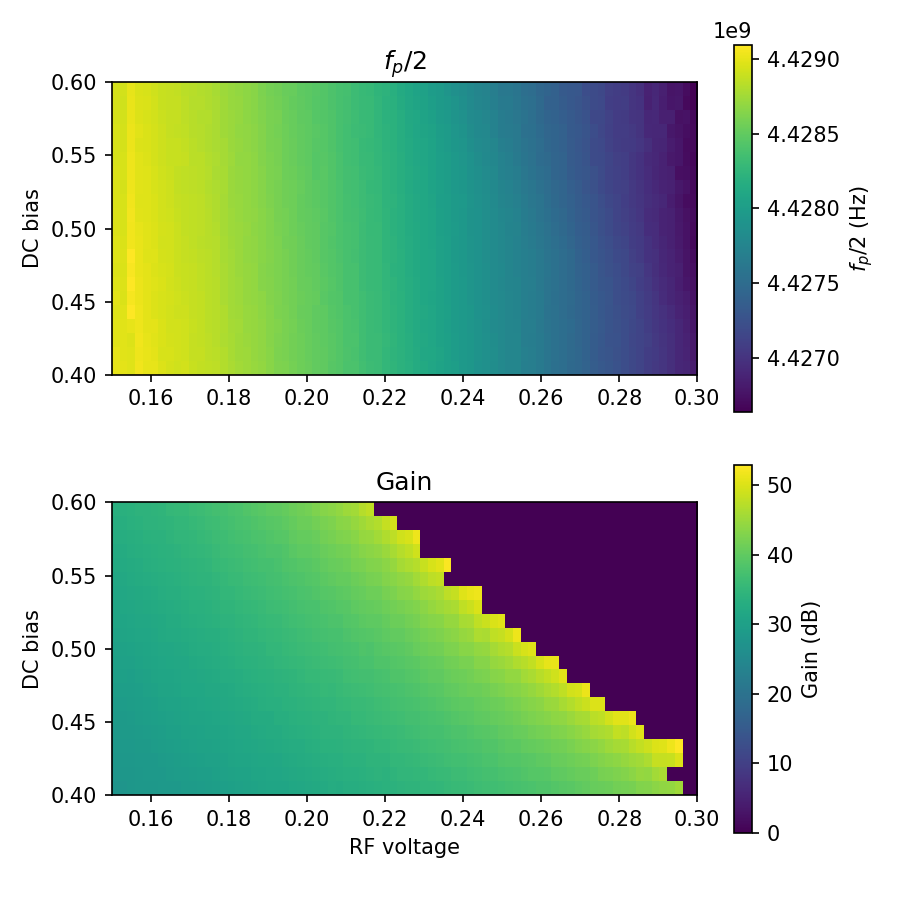

In [26]:
fig2, ax2 = plt.subplots(nrows=2, figsize=(6, 6), dpi=150)
ax21, ax22 = ax2

extent = [
    rf_unique[1], rf_unique[-1],   # x-axis
    dc_unique[1], dc_unique[-1]    # y-axis, flipped because origin='upper'
]

im1 = ax21.imshow(
    fp2_grid,
    cmap='viridis',
    origin='lower',
    aspect='auto',
    extent=extent
)

im2 = ax22.imshow(
    gain_grid,
    cmap='viridis',
    origin='lower',
    aspect='auto',
    extent=extent
)

ax21.set_ylabel("DC bias")
ax22.set_ylabel("DC bias")
ax22.set_xlabel("RF voltage")


ax21.set_box_aspect(0.5)
ax22.set_box_aspect(0.5)

ax21.set_title(r"$f_p/2$")
ax22.set_title("Gain")

fig2.colorbar(im1, ax=ax21, label=r"$f_p/2$ (Hz)")
fig2.colorbar(im2, ax=ax22, label="Gain (dB)")

plt.tight_layout()
plt.show()